# Day 14 — Trade
### #30DayChartChallenge | April 2026

**Shifting Trade Powers.** A bump chart showing how the top 10 exporting nations' rankings shifted from 2000 to 2023. 15 countries competed for the top 10 spots over 24 years.

**Data:** World Bank (NE.EXP.GNFS.CD) — Exports of goods and services, current US$  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(ggimage)
library(countrycode)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: sysfonts

Loading required package: showtextdb

Warning message:
"package 'ggimage' was built under R version 4.5.3"
Warning message:
"package 'countrycode' was built under R version 4.5.3"


In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 16, repr.plot.height = 10, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------
# Source: World Bank API (NE.EXP.GNFS.CD)
# Exports of goods and services, current US$, 2000-2023

df <- read.csv("../../data/day_14/exports_top_nations.csv",
               stringsAsFactors = FALSE)

# Countries ever in top 10, show only when ranked 1-10
ever_top10 <- df %>% filter(rank <= 10) %>% pull(iso3) %>% unique()
df_plot <- df %>% filter(iso3 %in% ever_top10, rank <= 10)

# Flags
df_plot$iso2 <- tolower(countrycode(df_plot$iso3, "iso3c", "iso2c",
  custom_match = c("HKG" = "hk")))
df_plot$flag_url <- paste0("https://flagcdn.com/w80/", df_plot$iso2, ".png")

start_df <- df_plot %>% filter(year == 2000) %>% select(iso3, country, rank, flag_url)
end_df <- df_plot %>% filter(year == 2023) %>% select(iso3, country, rank, flag_url)

head(df_plot)

,country,iso3,year,exports_usd,rank,iso2,flag_url
,<chr>,<chr>,<int>,<dbl>,<int>,<chr>,<chr>
1,Canada,CAN,2009,391985828012,10,ca,https://flagcdn.com/w80/ca.png
2,Canada,CAN,2008,534150890347,9,ca,https://flagcdn.com/w80/ca.png
3,Canada,CAN,2007,502770691742,9,ca,https://flagcdn.com/w80/ca.png
4,Canada,CAN,2006,467052186178,9,ca,https://flagcdn.com/w80/ca.png
5,Canada,CAN,2005,432369202839,9,ca,https://flagcdn.com/w80/ca.png
6,Canada,CAN,2004,383240584166,9,ca,https://flagcdn.com/w80/ca.png


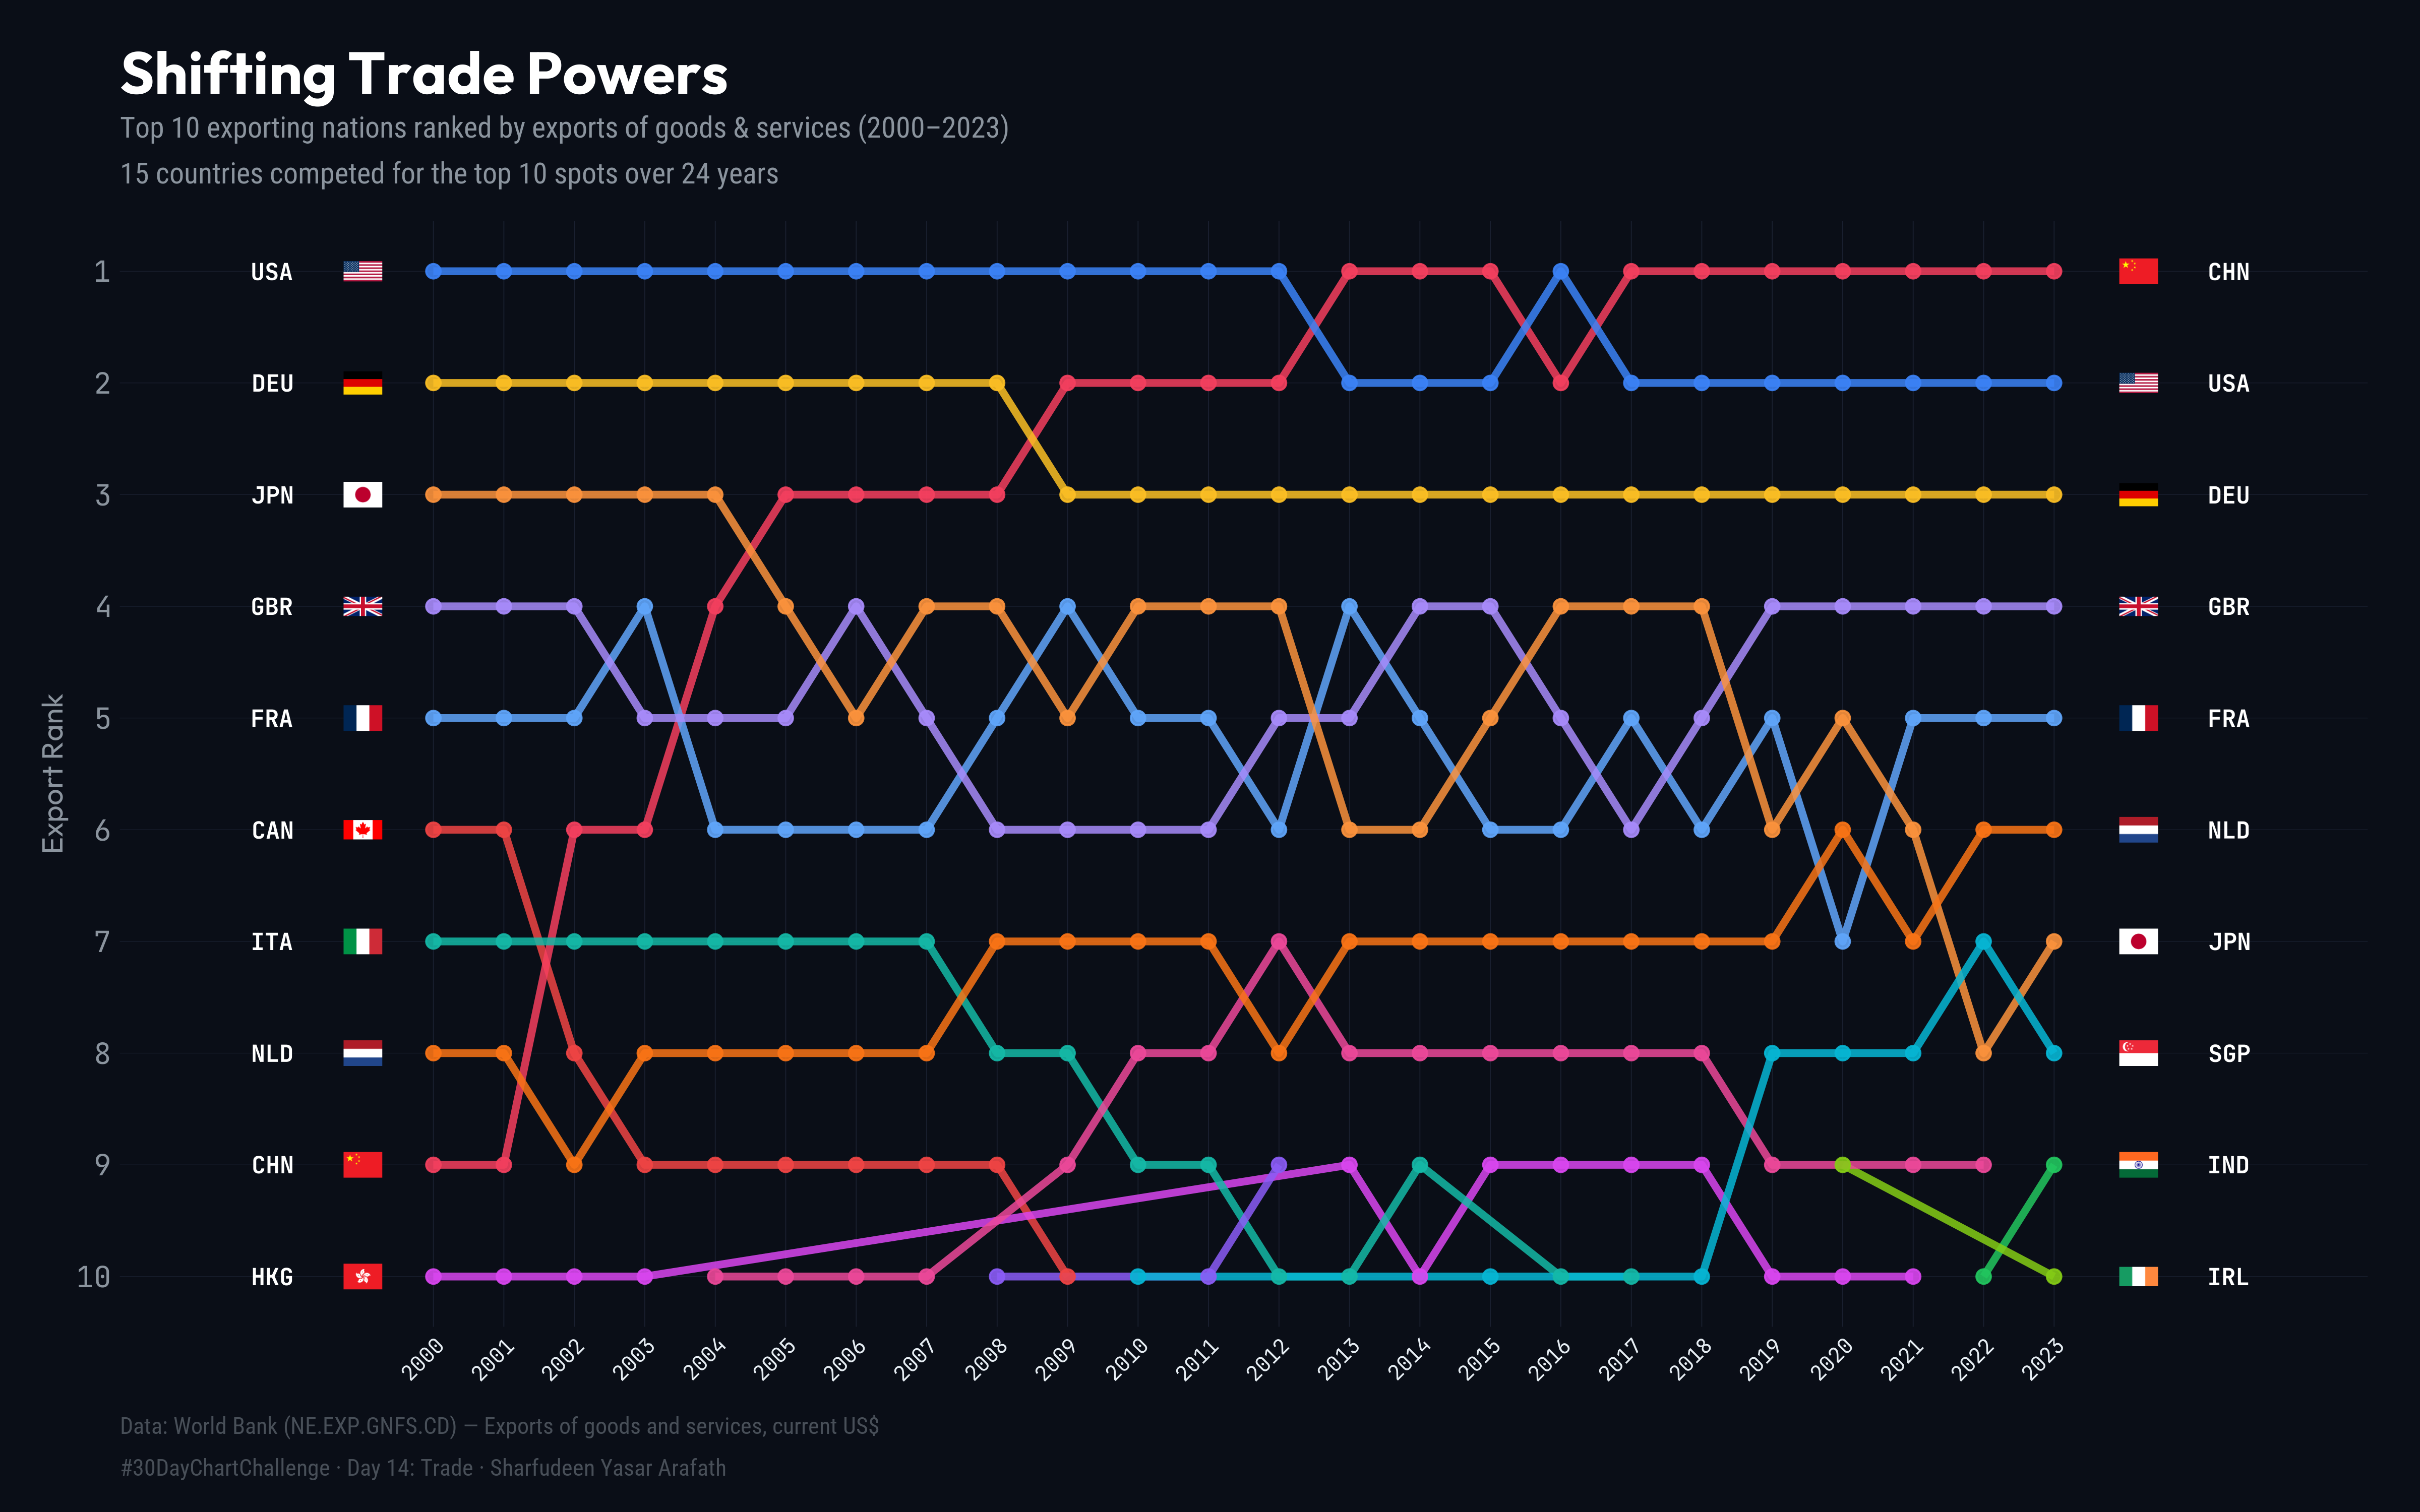

In [4]:
# — build the plot ------------------------------------------------------------

country_colors <- c(
  "CHN"="#F43F5E","USA"="#3B82F6","DEU"="#FBBF24","JPN"="#FB923C",
  "GBR"="#A78BFA","IND"="#22C55E","FRA"="#60A5FA","NLD"="#F97316",
  "CAN"="#EF4444","ITA"="#14B8A6","KOR"="#EC4899","RUS"="#8B5CF6",
  "SGP"="#06B6D4","IRL"="#84CC16","HKG"="#D946EF"
)

bg <- "#0a0e17"; txt <- "#E6EDF3"; txt_dim <- "#8B949E"
txt_cap <- "#484F58"; grid_col <- "#1a2030"

p <- ggplot(df_plot, aes(x = year, y = rank, group = iso3, color = iso3)) +
  geom_line(linewidth = 1.3, alpha = 0.85) +
  geom_point(size = 2.8, alpha = 0.9) +

  geom_image(data = start_df, aes(x = 1999, y = rank, image = flag_url),
    size = 0.035, inherit.aes = FALSE) +
  geom_image(data = end_df, aes(x = 2024.2, y = rank, image = flag_url),
    size = 0.035, inherit.aes = FALSE) +

  geom_text(data = start_df, aes(x = 1998, y = rank, label = iso3),
    inherit.aes = FALSE, family = "jetbrains", fontface = "bold",
    size = 4, color = "#FFFFFF", hjust = 1) +
  geom_text(data = end_df, aes(x = 2025.2, y = rank, label = iso3),
    inherit.aes = FALSE, family = "jetbrains", fontface = "bold",
    size = 4, color = "#FFFFFF", hjust = 0) +

  scale_y_reverse(breaks = 1:10) +
  scale_x_continuous(breaks = 2000:2023, minor_breaks = NULL) +
  scale_color_manual(values = country_colors, guide = "none") +

  coord_cartesian(clip = "off", xlim = c(1997, 2026)) +

  labs(
    title = "Shifting Trade Powers",
    subtitle = paste0(
      "Top 10 exporting nations ranked by exports of goods & services (2000\u20132023)\n",
      "15 countries competed for the top 10 spots over 24 years"
    ),
    x = NULL, y = "Export Rank",
    caption = paste0(
      "Data: World Bank (NE.EXP.GNFS.CD) \u2014 Exports of goods and services, current US$\n",
      "#30DayChartChallenge \u00b7 Day 14: Trade \u00b7 Sharfudeen Yasar Arafath"
    )
  ) +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 28,
      color = "#FFFFFF", margin = margin(t = 10, b = 5)),
    plot.subtitle = element_text(size = 14, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 15)),
    plot.caption = element_text(size = 11, hjust = 0, color = txt_cap,
      lineheight = 1.5, margin = margin(t = 15)),
    axis.text.x = element_text(size = 10, color = txt, family = "jetbrains",
      angle = 45, hjust = 1),
    axis.text.y = element_text(size = 14, color = txt_dim, family = "jetbrains"),
    axis.title.y = element_text(size = 14, color = txt_dim, family = "outfit"),
    panel.grid.major.x = element_line(color = grid_col, linewidth = 0.15),
    panel.grid.major.y = element_line(color = grid_col, linewidth = 0.1),
    panel.grid.minor = element_blank(),
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 25, 15, 20)
  )

p

In [5]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_14_trade.png",
       plot = p, width = 16, height = 10, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_14_trade.png\n")

Done — saved to chart/day_14_trade.png
